<div style="background-color:#000;"><img src="pqn.png"></img></div><div><a href="https://pyquantnews.com/">PyQuant News</a> is where finance practitioners level up with Python for quant finance, algorithmic trading, and market data analysis. Looking to get started? Check out the fastest growing, top-selling course to <a href="https://www.pyquantnews.com/getting-started-with-python-for-quant-finance/">get started with Python for quant finance</a>. For educational purposes. Not investment advice. Use at your own risk.</div>

## Library installation

This installs the numerical computing and scientific optimization libraries needed for the notebook.

In [ ]:
!pip install numpy scipy

The OpenBB SDK requires a separate installation process with its own dependencies and terminal setup. Visit the OpenBB documentation for platform-specific instructions before running this notebook.

## Imports and setup

We use numpy for numerical operations, scipy for integration (quad), optimization (minimize_scalar), and probability distributions (norm), and openbb for pulling historical S&P 500 price data directly into pandas.

In [1]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import minimize_scalar
from scipy.stats import norm
import yfinance as yf

## Fetch and prepare annual return data

We pull S&P 500 closing prices going back to 1950, resample them to annual frequency, and compute year-over-year percentage returns.

In [3]:
annual_returns = (
    yf.download(
        ["^GSPC"],
        start="1950-01-01",
    )
    .Close
    .resample("YE")
    .last()
    .pct_change()
    .dropna()
)

[*********************100%***********************]  1 of 1 completed


The Kelly criterion needs estimates of how your asset behaves over time, specifically its average return and volatility. Working with annual returns keeps the math clean and gives us over 70 years of data points to learn from.

We compute rolling 25-year mean and standard deviation to capture how the S&P 500's return profile shifts across different market regimes.

In [4]:
return_params = (
    annual_returns["^GSPC"]
    .rolling(25)
    .agg(["mean", "std"])
    .dropna()
)

A 25-year rolling window is long enough to smooth out individual bull and bear markets but short enough to adapt as the market's character changes. These two parameters, mean and standard deviation, define the normal distribution we feed into the Kelly formula at each point in time.

## Define the Kelly criterion functions

This function computes the expected logarithmic growth rate for a given fraction f of our account, assuming returns follow a normal distribution. We negate the result because our optimizer minimizes, and we want to maximize growth.

In [5]:
def norm_integral(f, mean, std):
    val, er = quad(
        lambda s: np.log(1 + f * s) * norm.pdf(s, mean, std),
        mean - 3 * std,
        mean + 3 * std,
    )
    return -val

The integral inside this function is the core of the Kelly criterion for continuous distributions. Instead of the simple win/loss version you see in textbook gambling examples, this version handles the full range of possible returns weighted by how likely each one is. Integrating over plus or minus three standard deviations captures about 99.7% of outcomes.

This wrapper applies the optimizer to each row of our rolling parameters, finding the fraction f between 0 and 2 that maximizes long-run growth.

In [6]:
def get_kelly(data):
    solution = minimize_scalar(
        norm_integral,
        args=(data["mean"], data["std"]),
        bounds=[0, 2],
        method="bounded",
    )
    return solution.x

Bounding f between 0 and 2 means we consider allocations from 0% up to 200% of our account (i.e., up to 2x leverage). The optimizer searches this range for the single fraction that would have grown our account fastest given the historical return profile. In practice, professionals often use half the Kelly fraction or less because the formula assumes perfect knowledge of the return distribution, which we never actually have.

## Backtest Kelly-sized positions against buy and hold

We apply the Kelly fraction from the previous year's rolling window to size each year's position, then compare cumulative returns of the Kelly-sized strategy against a simple buy-and-hold of the S&P 500.

<Axes: xlabel='Date'>

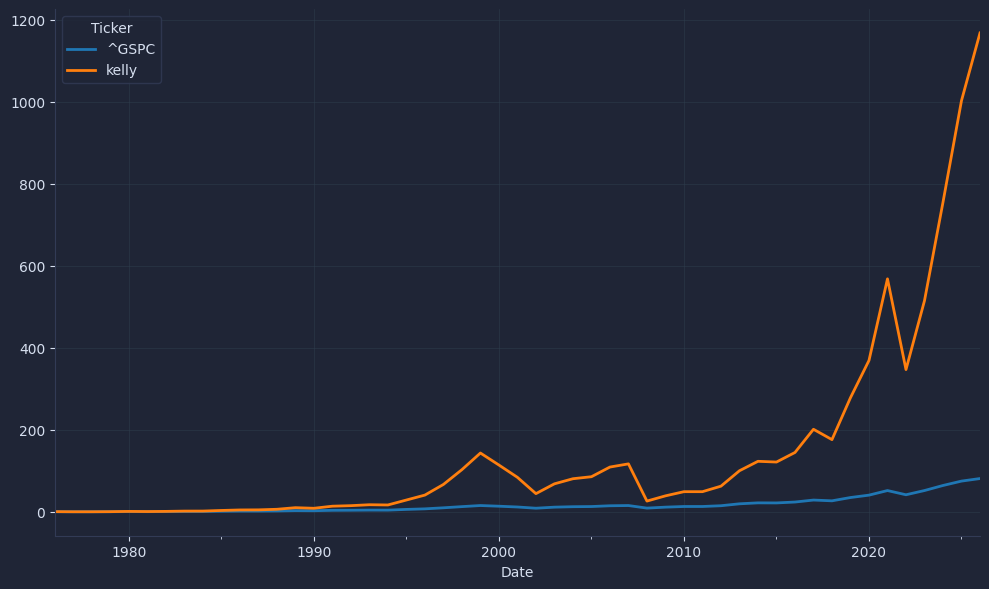

In [7]:
annual_returns['f'] = return_params.apply(get_kelly, axis=1)
(
    annual_returns[["^GSPC"]]
    .assign(
        kelly=annual_returns["^GSPC"].mul(
            annual_returns.f.shift()
        )
    )
    .dropna()
    .loc["1900":]
    .add(1)
    .cumprod()
    .sub(1)
    .plot(lw=2)
)

The shift() call is critical here. It ensures we size this year's position using last year's Kelly fraction, which prevents lookahead bias, meaning we never use information we wouldn't have had at the time. This is the same discipline professional quant teams follow when backtesting any strategy. The resulting chart shows whether dynamically adjusting position size based on the Kelly criterion would have outperformed simply holding the S&P 500 with a fixed allocation over decades of real market history.

<a href="https://pyquantnews.com/">PyQuant News</a> is where finance practitioners level up with Python for quant finance, algorithmic trading, and market data analysis. Looking to get started? Check out the fastest growing, top-selling course to <a href="https://www.pyquantnews.com/getting-started-with-python-for-quant-finance/">get started with Python for quant finance</a>. For educational purposes. Not investment advice. Use at your own risk.